----------------------------------------------------------------------------------------------------

# ***Construtores e Destrutores - Dunder Methods***

----------------------------------------------------------------------------------------------------

Na Programação Orientada a Objetos em Python, os construtores e destrutores são *"métodos especiais"* (também chamados de dunder methods por causa dos dois sublinhados) que gerenciam o ciclo de vida de um objeto: desde o momento em que ele "nasce" na memória até o momento em que ele é descartado.

----------------------------------------------------------------------------------------------------

## ***1. O Construtor: _ _init_ _***

Diferente de outras linguagens onde o construtor cria o objeto, no Python o _ _init_ _ serve para inicializar o objeto que já foi criado. Ele define o estado inicial (atributos) da instância.

- Quando é chamado? Automaticamente assim que você faz objeto = MinhaClasse().

- O que faz? Configura os valores iniciais que o objeto precisa para funcionar.

In [1]:
class Robo:
    def __init__(self, nome, versao):
        self.nome = nome
        self.versao = versao

        print(f"Robô {self.nome} inicializado e pronto para operar.")

meu_robo = Robo("R2-D2", 1.0)

print(meu_robo)

Robô R2-D2 inicializado e pronto para operar.


### ***O segredo do _ _new_ _ (O Construtor Real)***

Embora quase todo mundo chame o _ _init_ _ de construtor, tecnicamente o método que cria a instância na memória é o _ _new_ _. 

Você raramente precisará mexer nele, a menos que esteja fazendo algo muito avançado, como criar uma classe que só permite uma única instância (Singleton).

----------------------------------------------------------------------------------------------------

## ***2. O Destrutor: _ _del_ _***

O método _ _del_ _ é o oposto do construtor. Ele define o que deve acontecer quando o objeto está prestes a ser destruído.

- Quando é chamado? Quando a contagem de referências do objeto chega a zero (ninguém mais está usando ele) ou quando o programa termina. O responsável por isso é o 'Garbage Collector' (Coletor de Lixo) do Python.

- O que faz? Geralmente é usado para fechar conexões de banco de dados, fechar arquivos abertos ou encerrar processos externos.

In [2]:
class ArquivoTemporario:
    def __init__(self, nome):
        self.nome = nome
        print(f"Arquivo {self.nome} aberto.")

    def __del__(self):
        print(f"Limpando resíduos... Arquivo {self.nome} fechado com segurança.")

# Ao deletar a referência ou o programa acabar, o __del__ será chamado
temp = ArquivoTemporario("dados.txt")
del temp  # Força a destruição da referência

Arquivo dados.txt aberto.
Limpando resíduos... Arquivo dados.txt fechado com segurança.


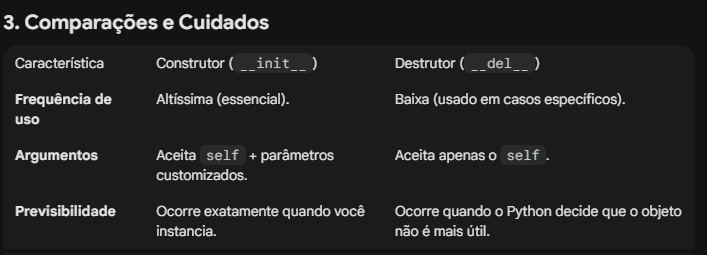

### ***Cuidado com o _ _del_ _!***
No Python, você não deve confiar 100% no momento exato em que o _ _del_ _ será executado. Se houver "referências circulares" (o Objeto A aponta para o B, e o B aponta para o A), o Python pode demorar para destruí-los.

- ***Dica de ouro***: Para garantir que arquivos ou conexões sejam fechados na hora certa, é melhor usar o comando with (Gerenciadores de Contexto), que usa os métodos _ _enter_ _ e _ _exit_ _.

In [ ]:
class ConexaoBanco:
    def __init__(self, banco):
        self.banco = banco
        print(f"Conectado ao banco: {self.banco}")

    def consultar(self, query):
        print(f"Executando '{query}' no {self.banco}...")

    def __del__(self):
        print(f"Encerrando conexão com {self.banco}. Tchau!")

# Criando e usando
db = ConexaoBanco("Vendas_DB")
db.consultar("SELECT * FROM produtos")

# O destrutor será chamado automaticamente ao final do script

## ***Resumo:***
_ _init_ _: Dá vida e atributos ao seu objeto.

_ _del_ _: Faz a limpeza antes do objeto sumir da memória.